# Upscaled Map of Defoliation
This is a test for the best method for creating maps of defoliation across the continent. Upscaling was implemented on GEE, then upscaled tiles were downloaded for creating this map. If further upscaling is used here, it will result in a statistically inaccurate map as it will not weight averages by forest area.

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import rasterio as rio
from rasterio.plot import show
import ultraplot as uplt

In [2]:
def permute_bounds(bounds):
    return [bounds[0], bounds[2], bounds[1], bounds[3]]

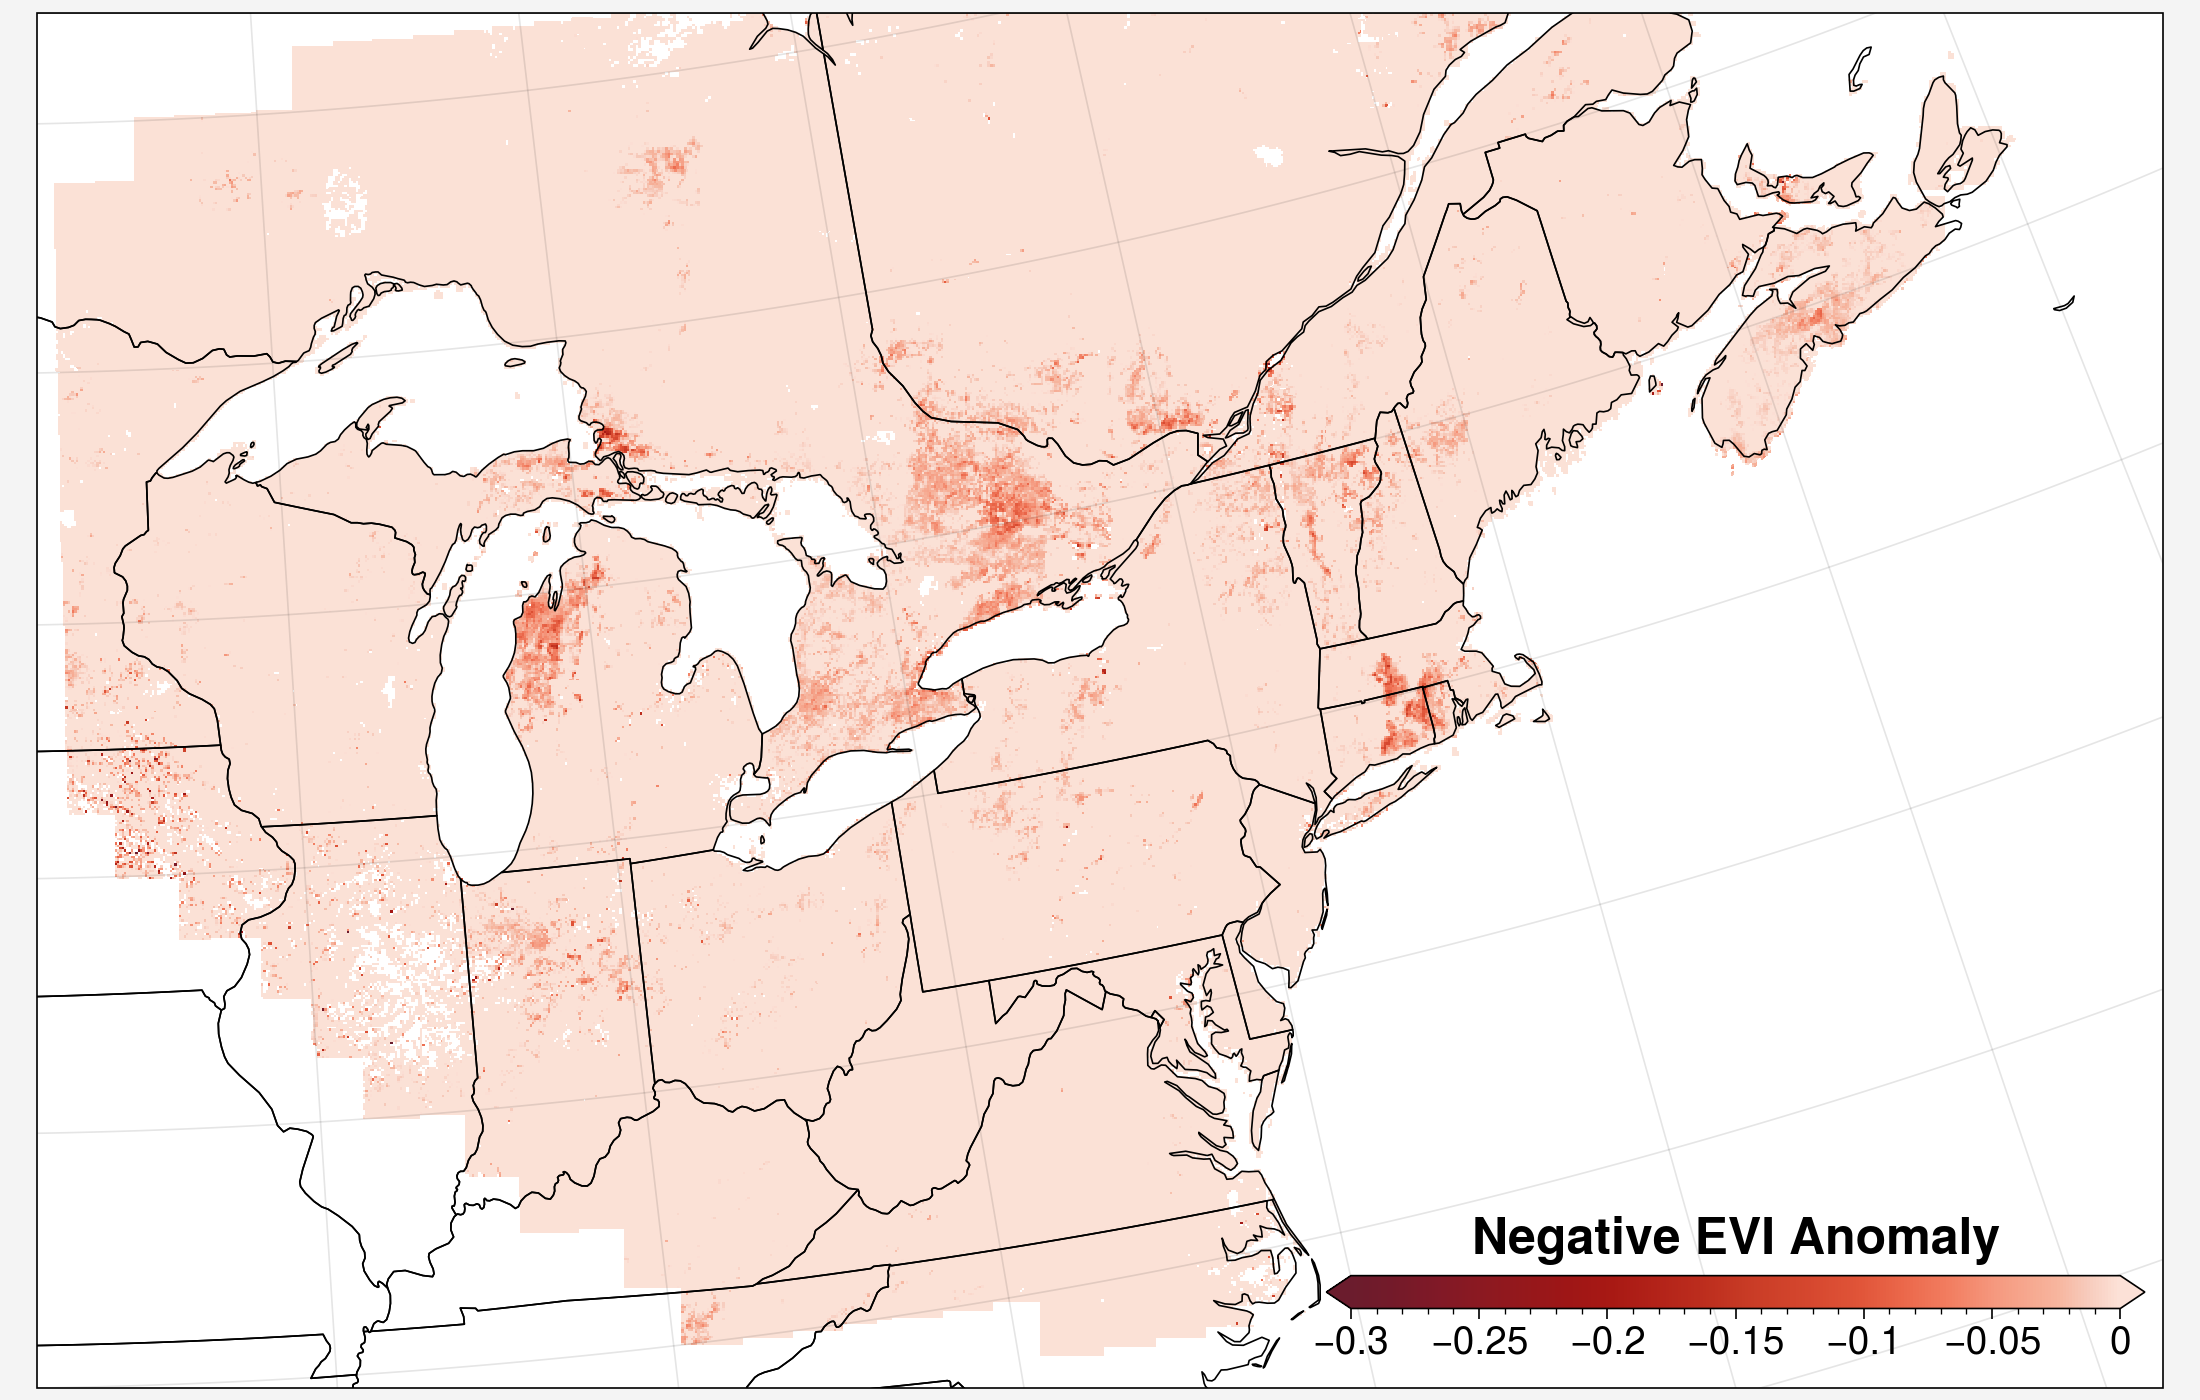

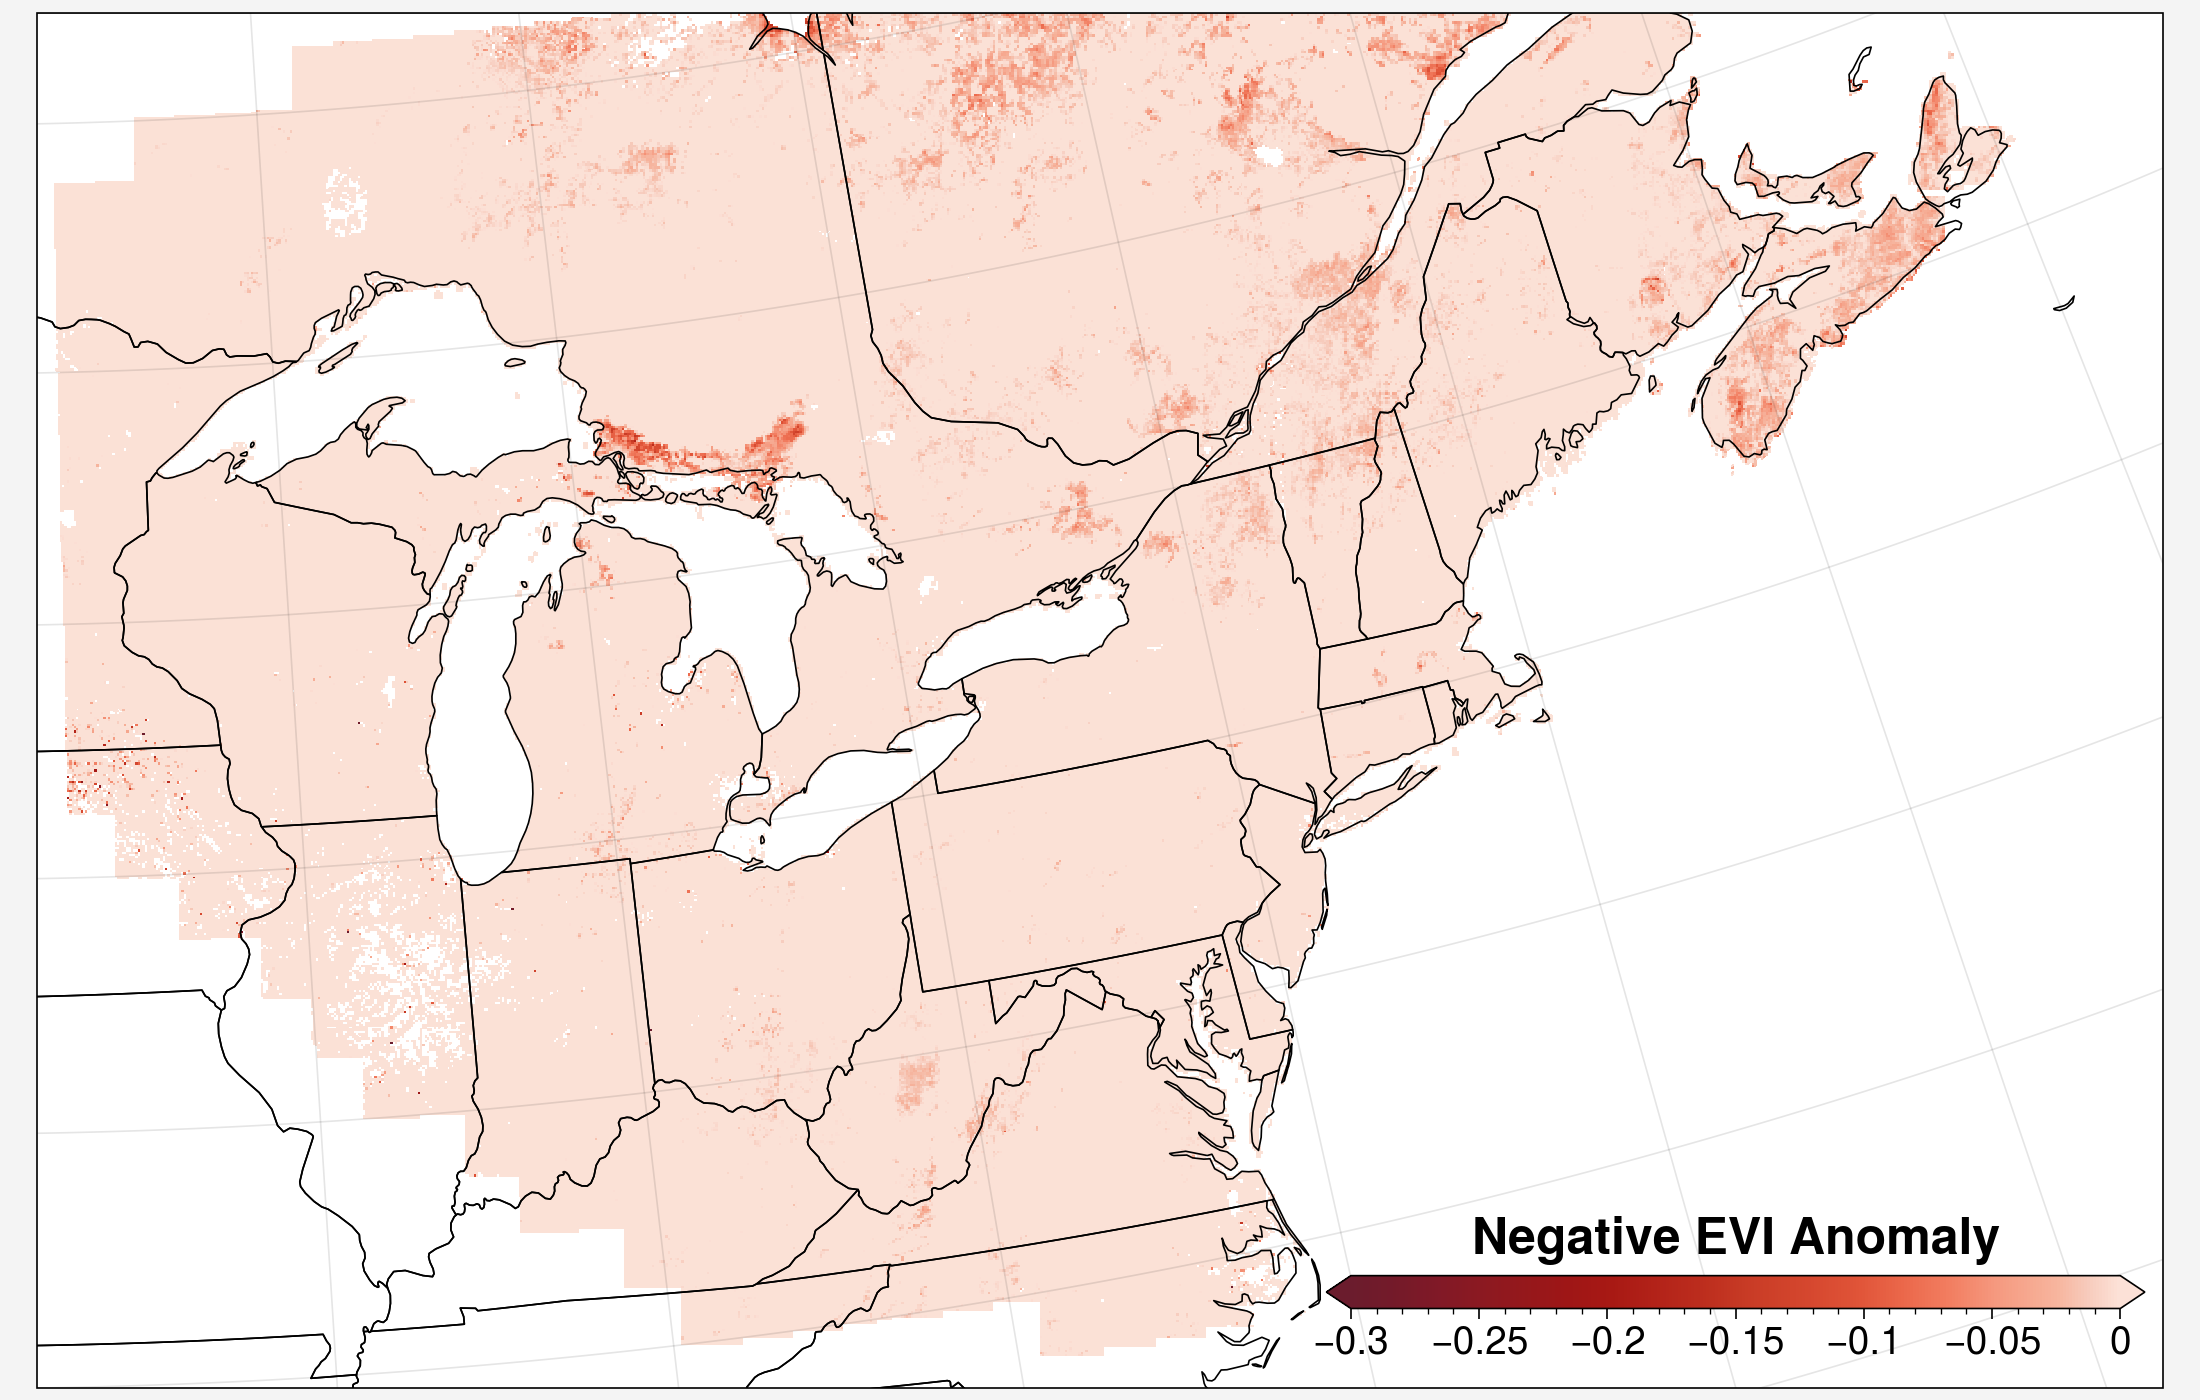

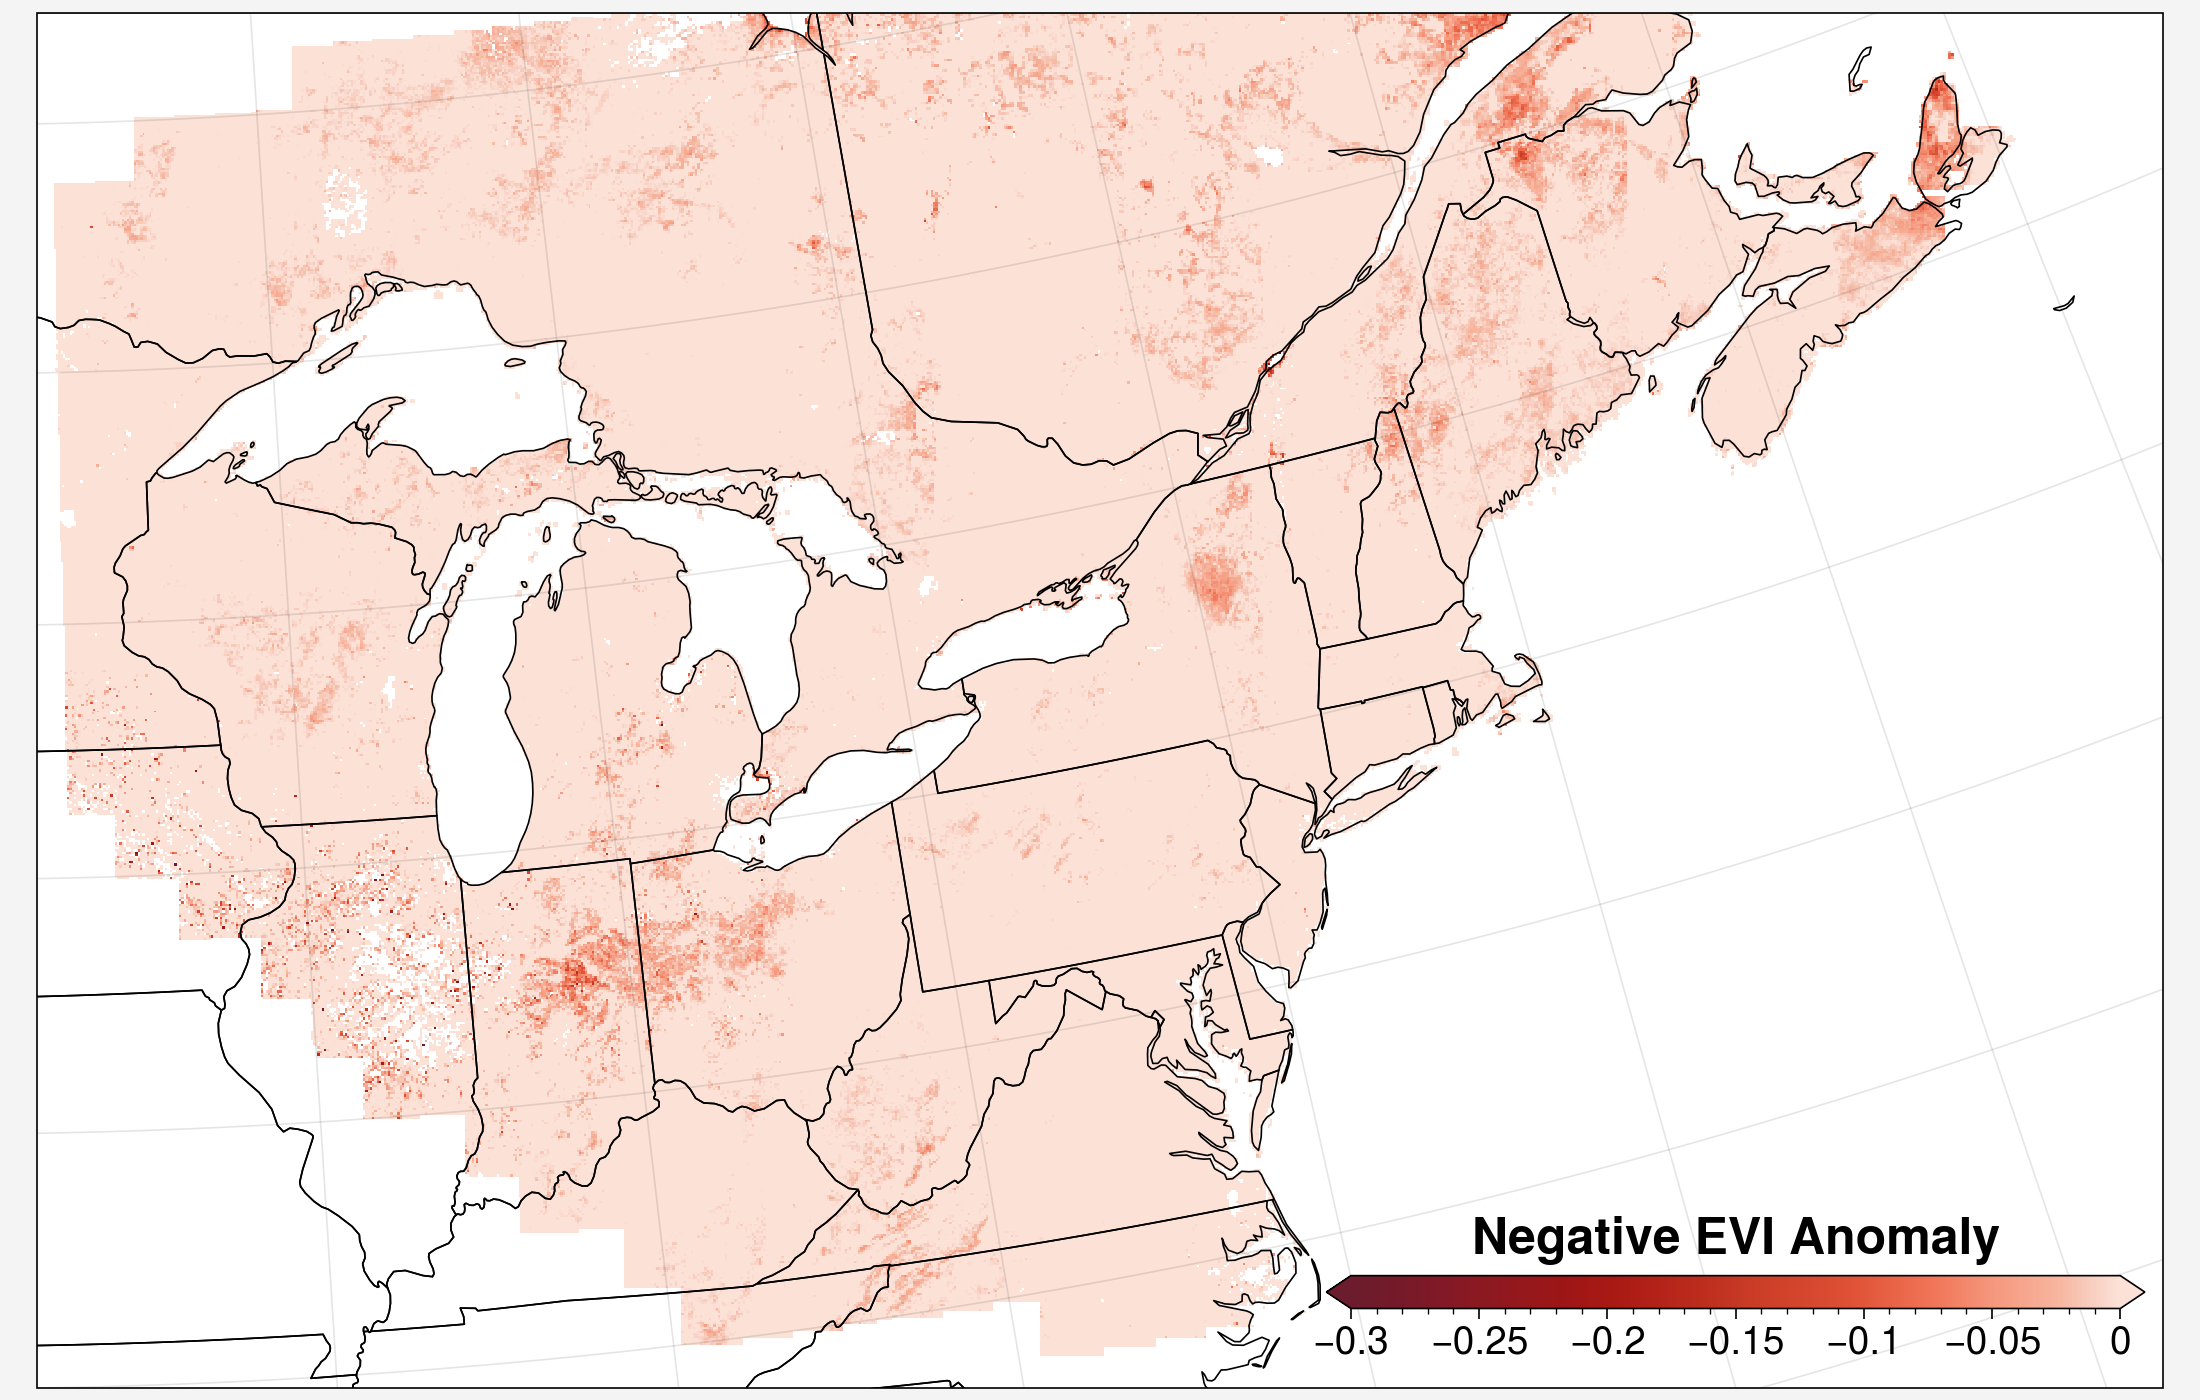

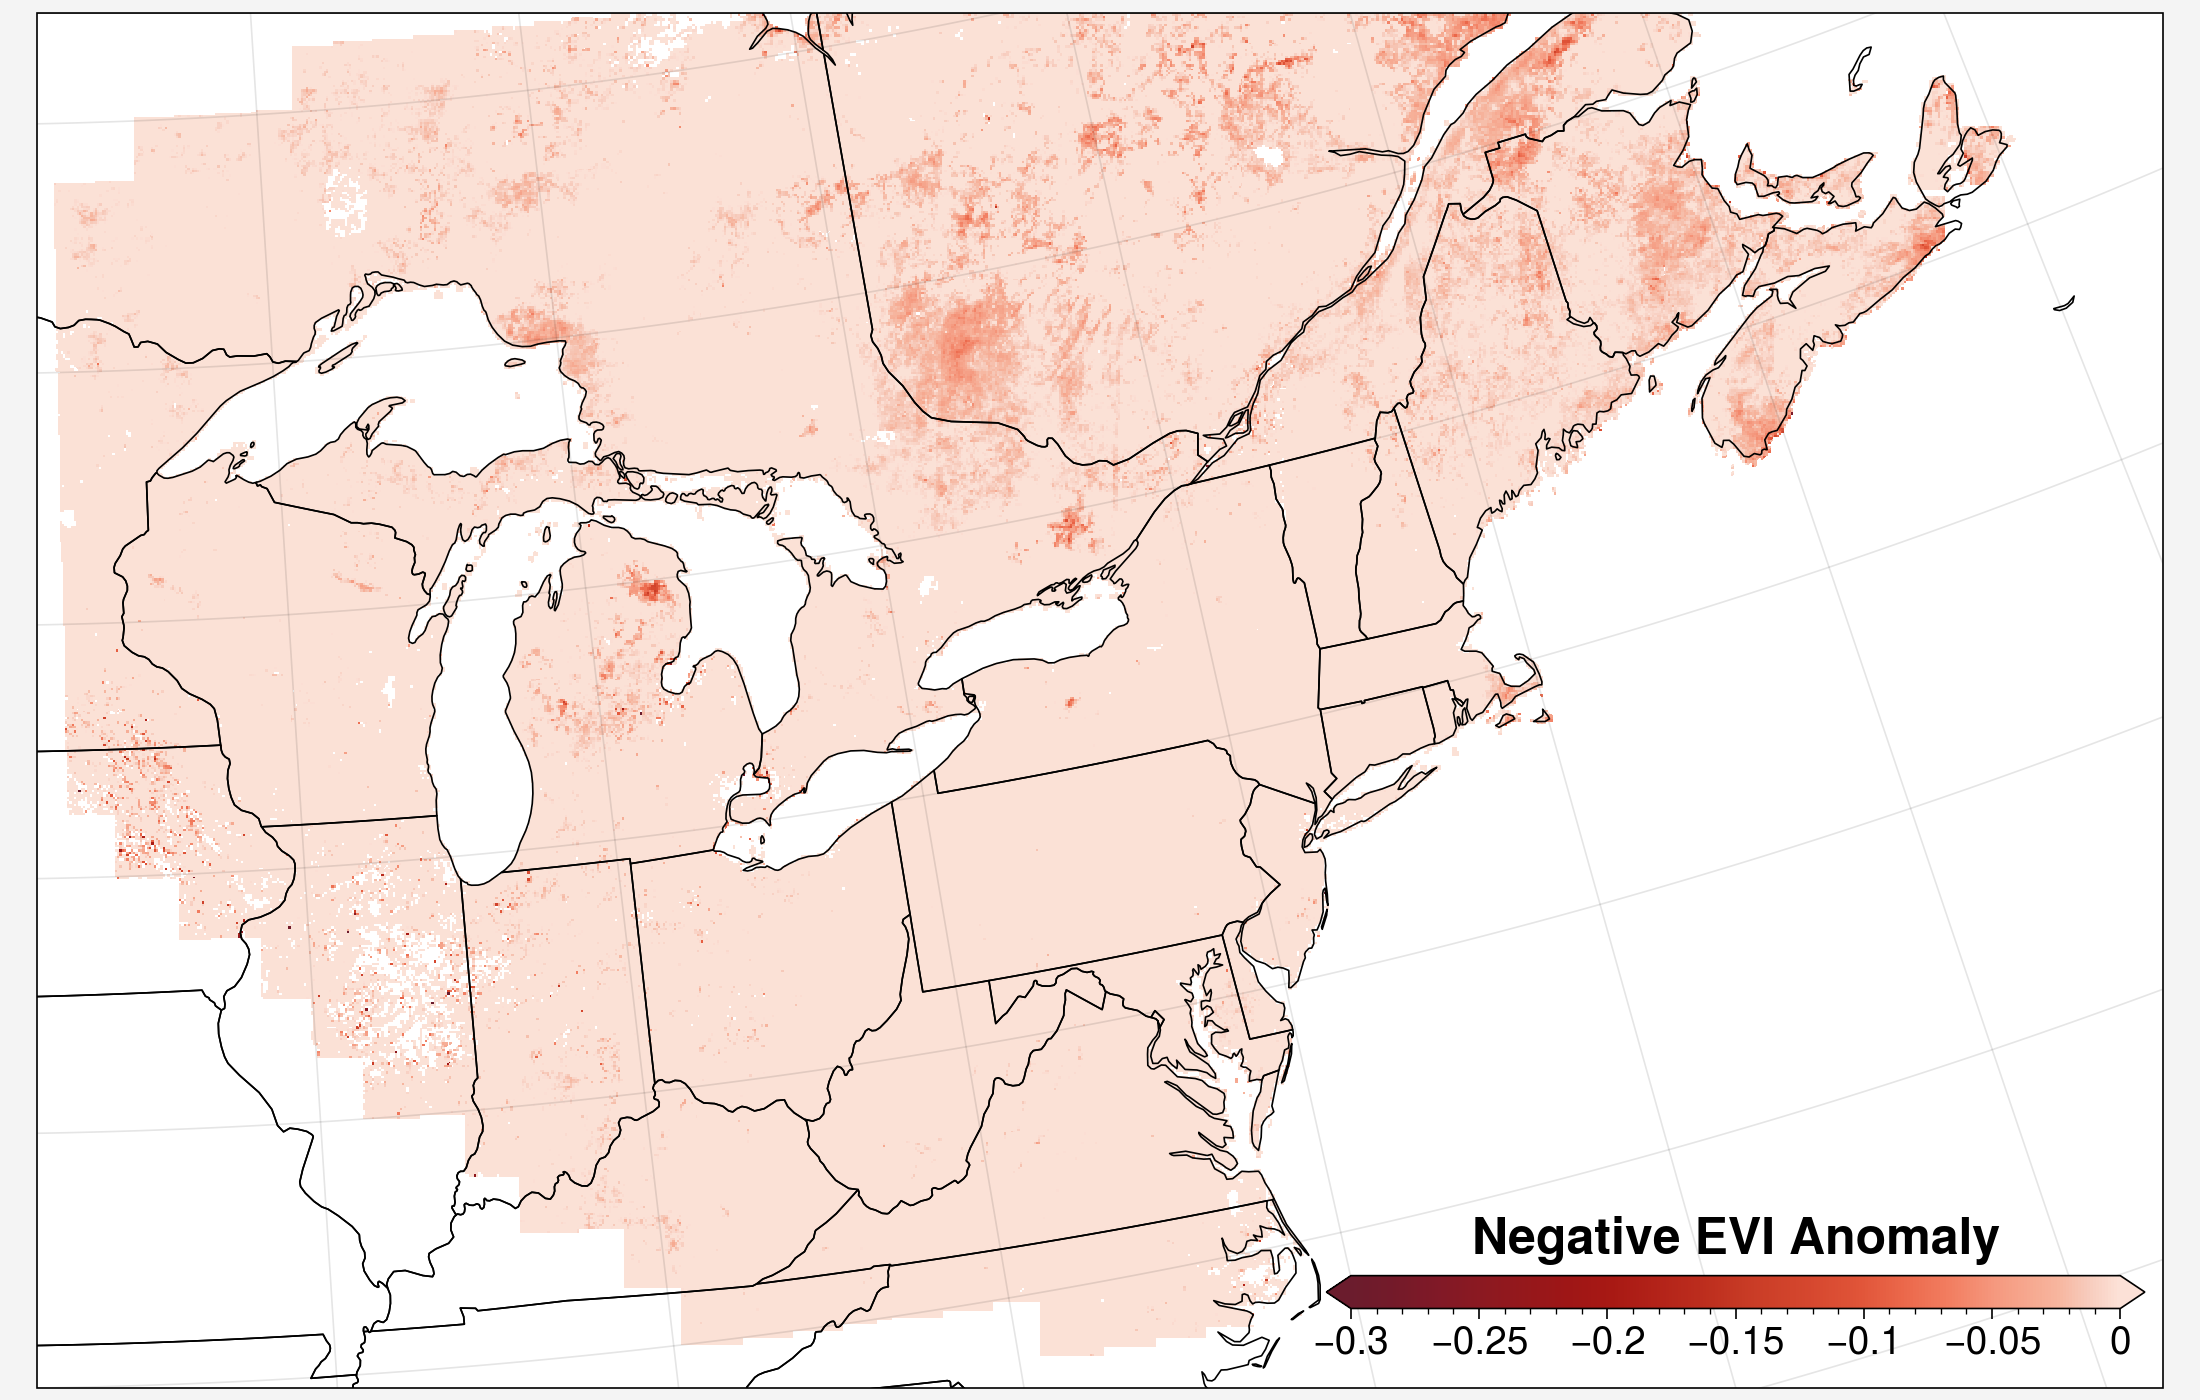

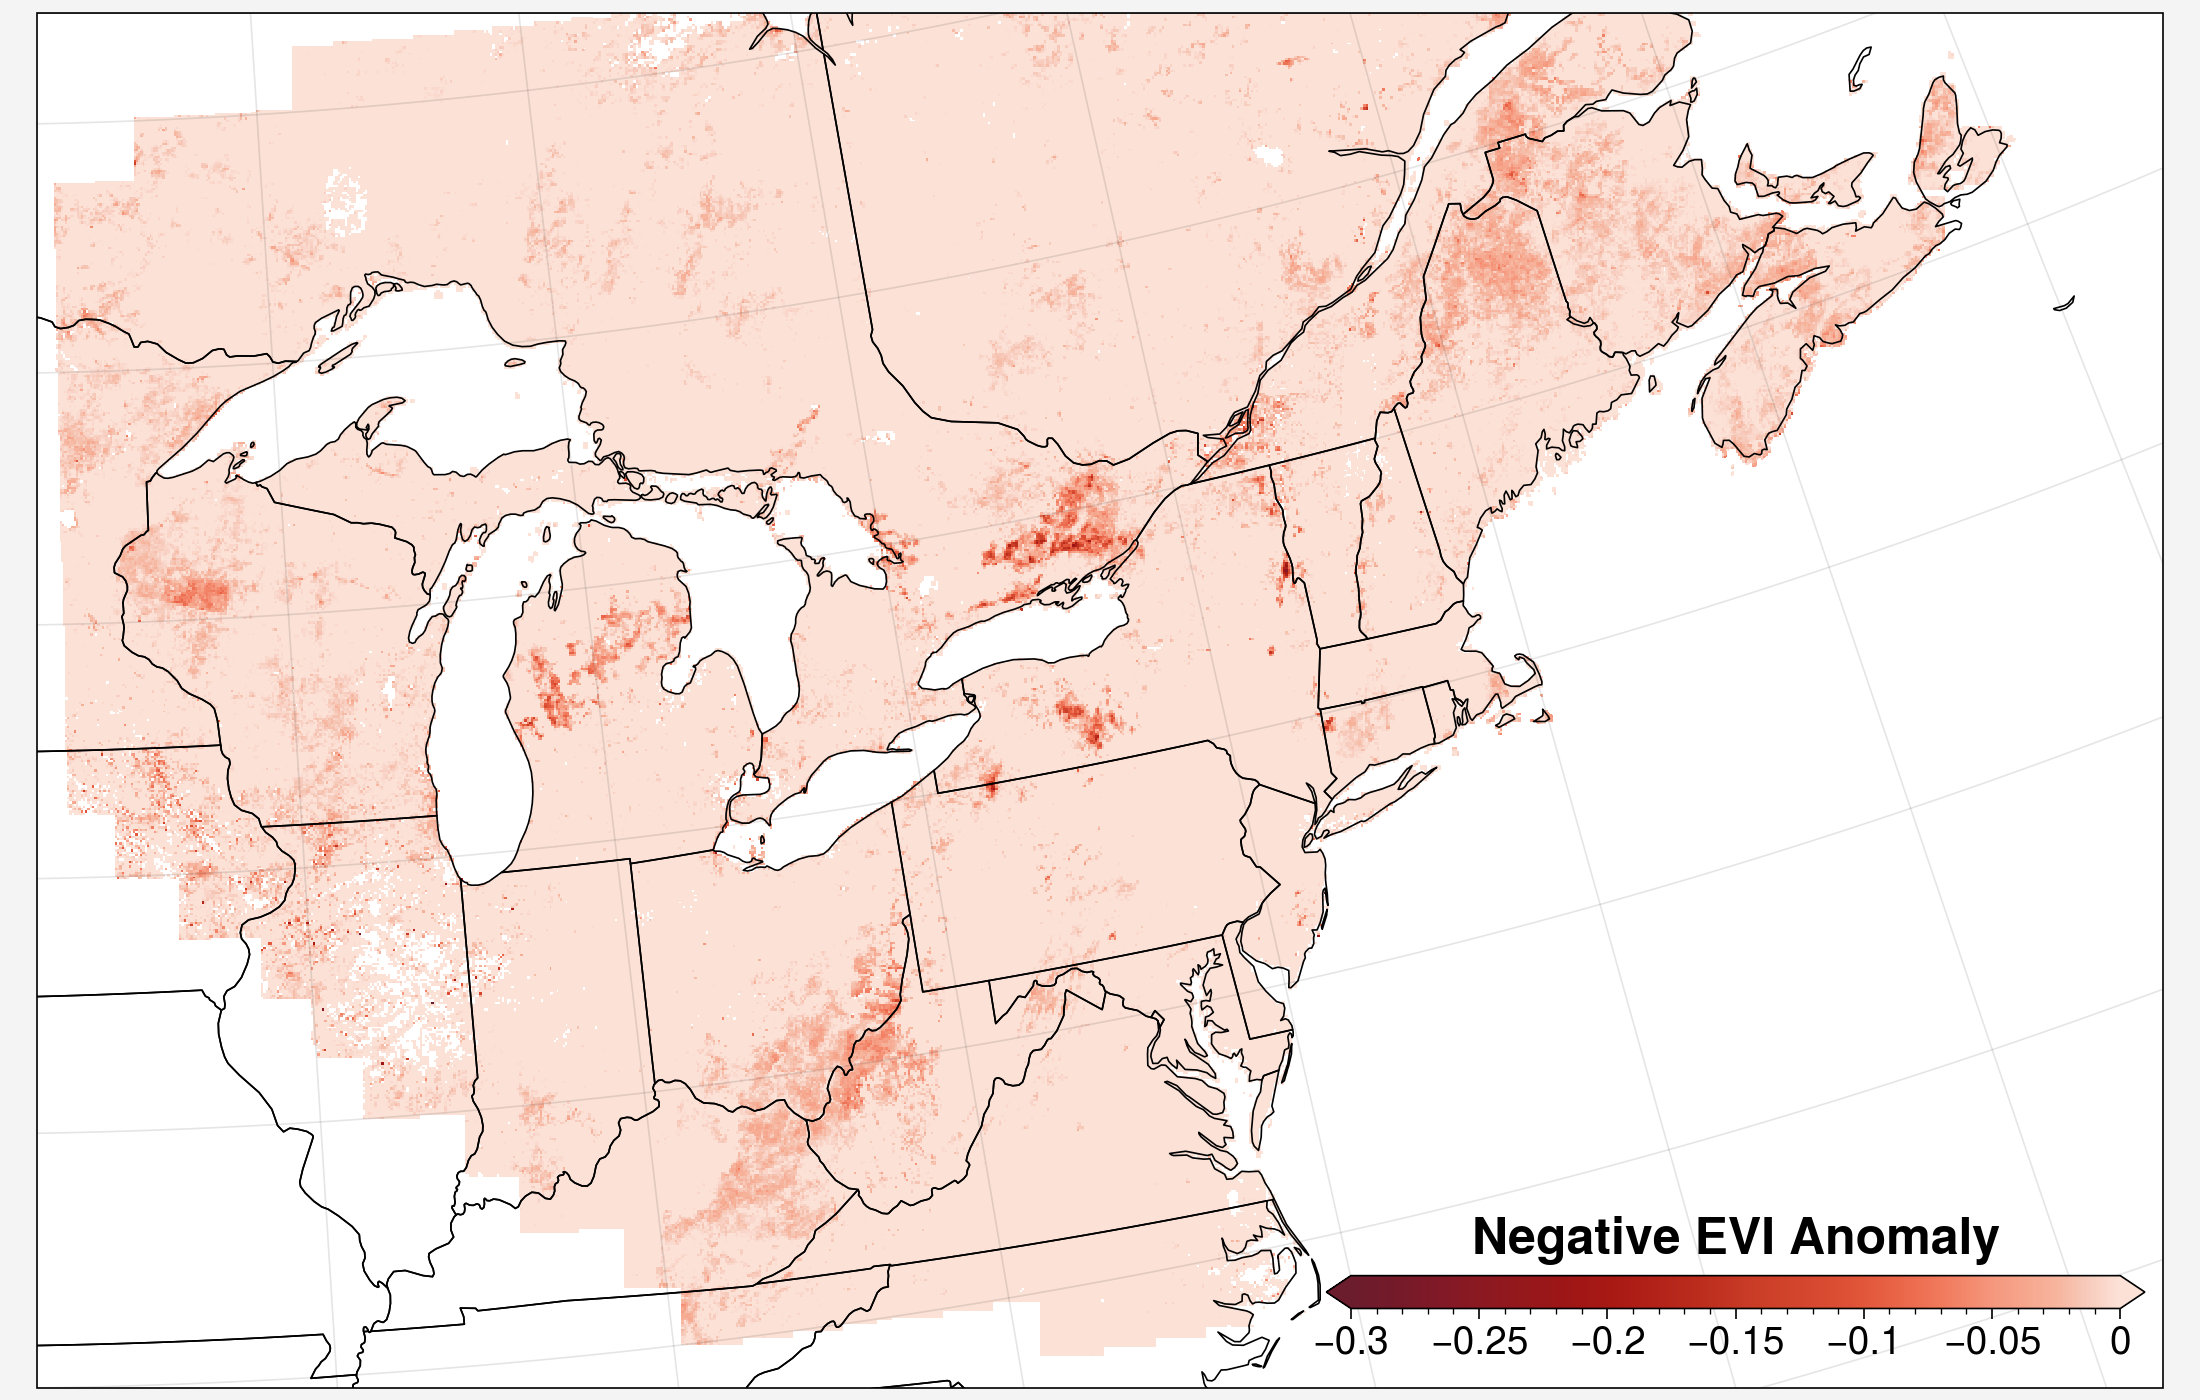

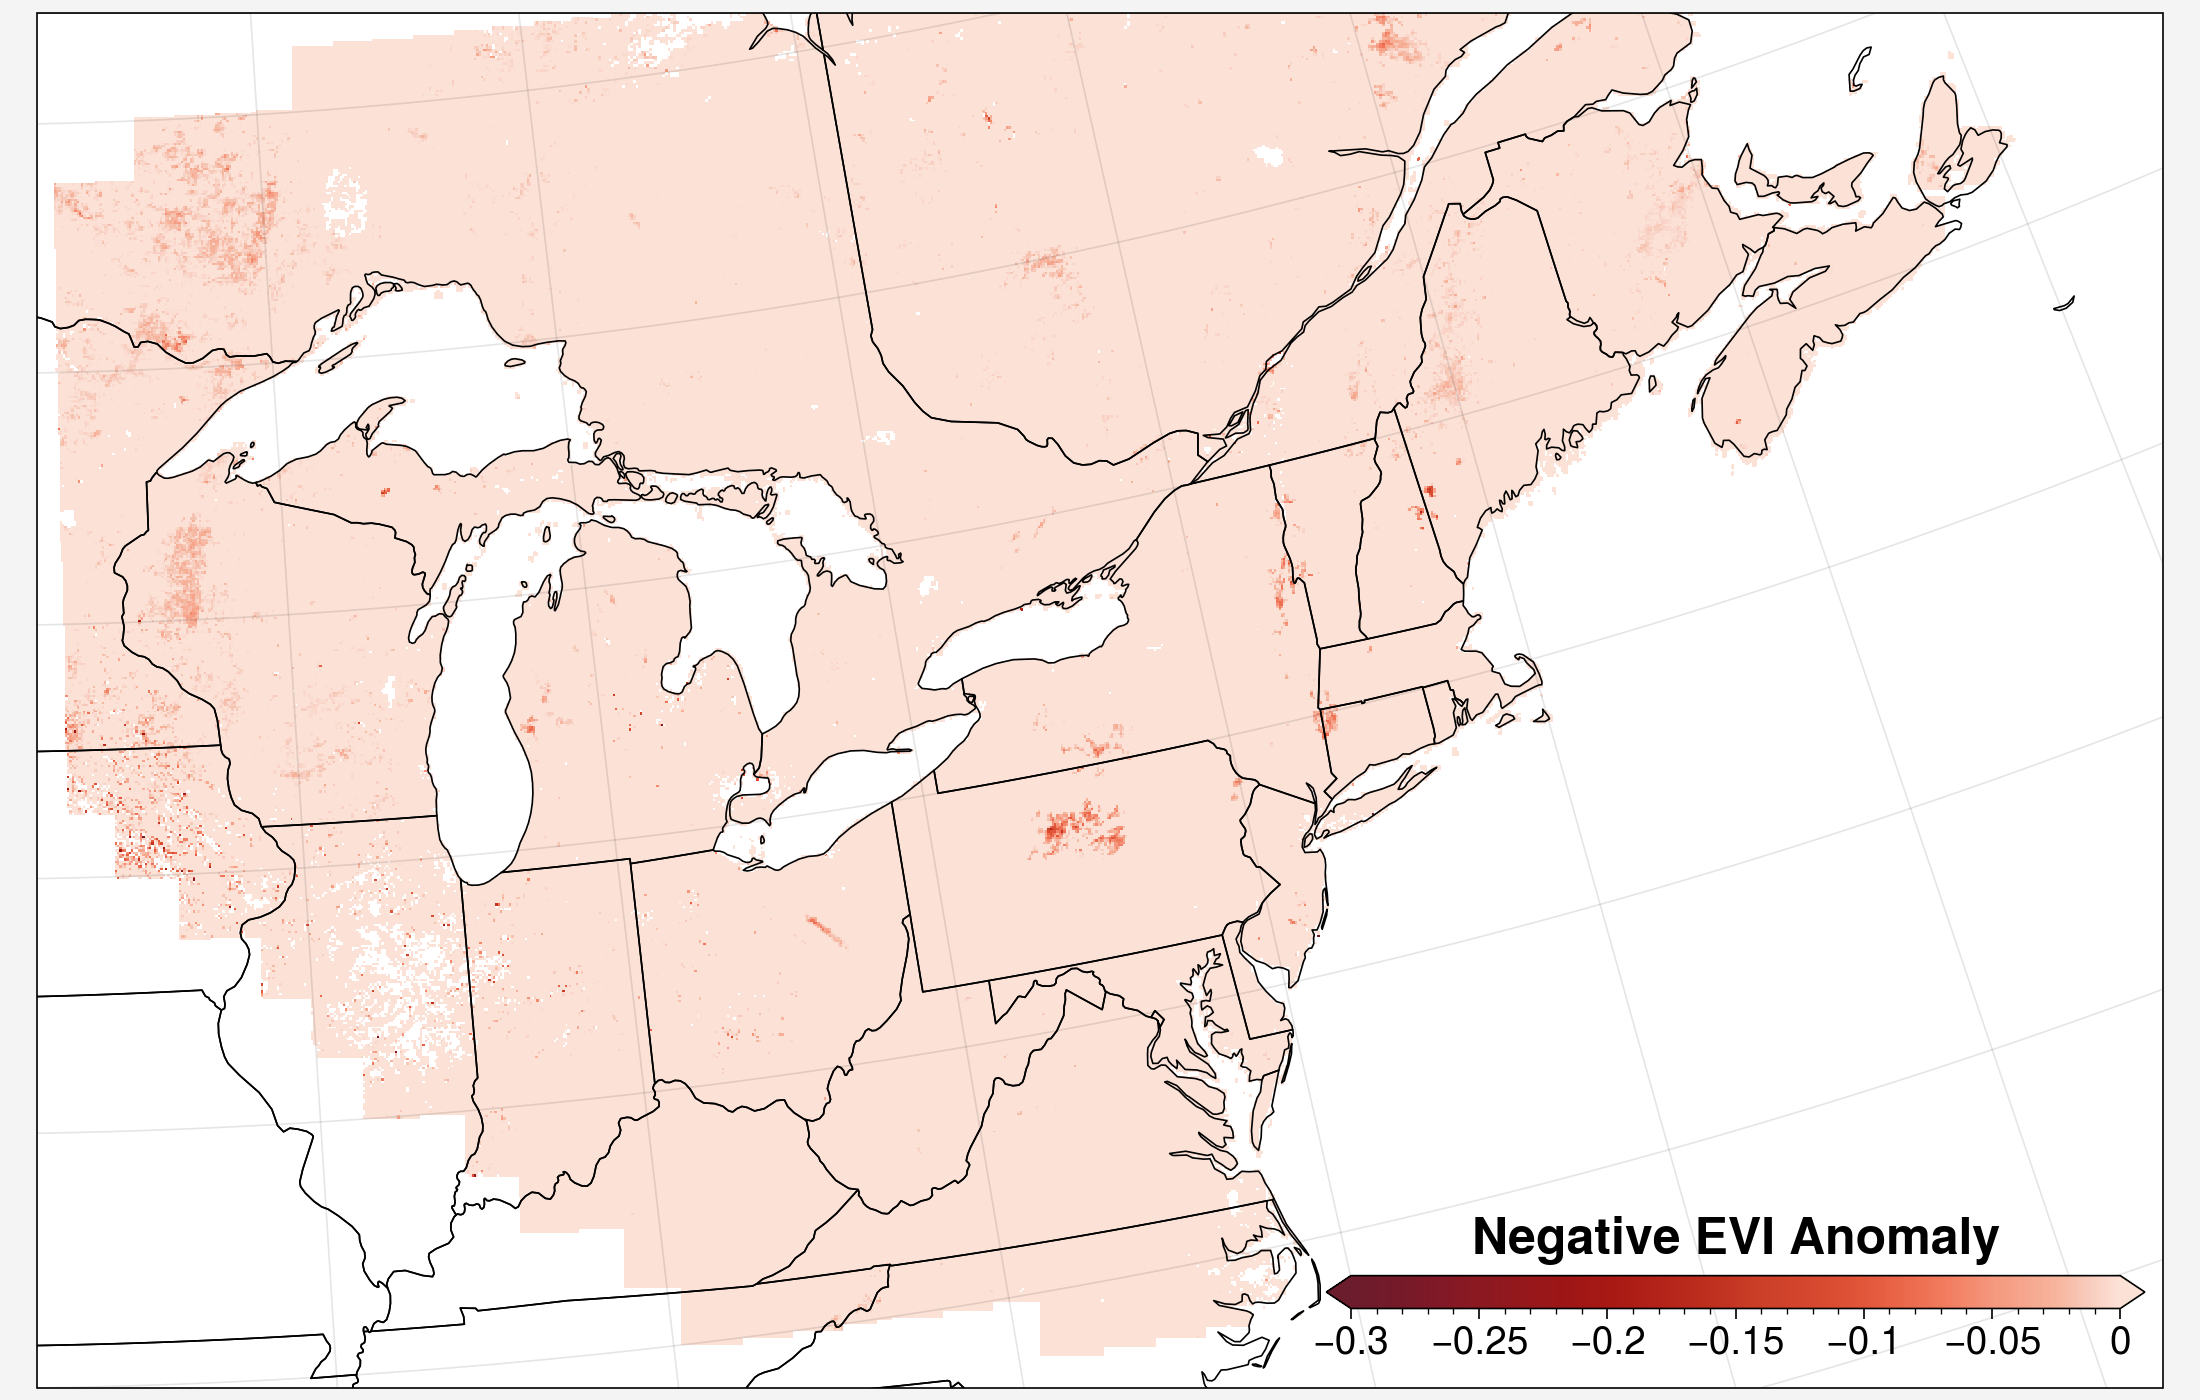

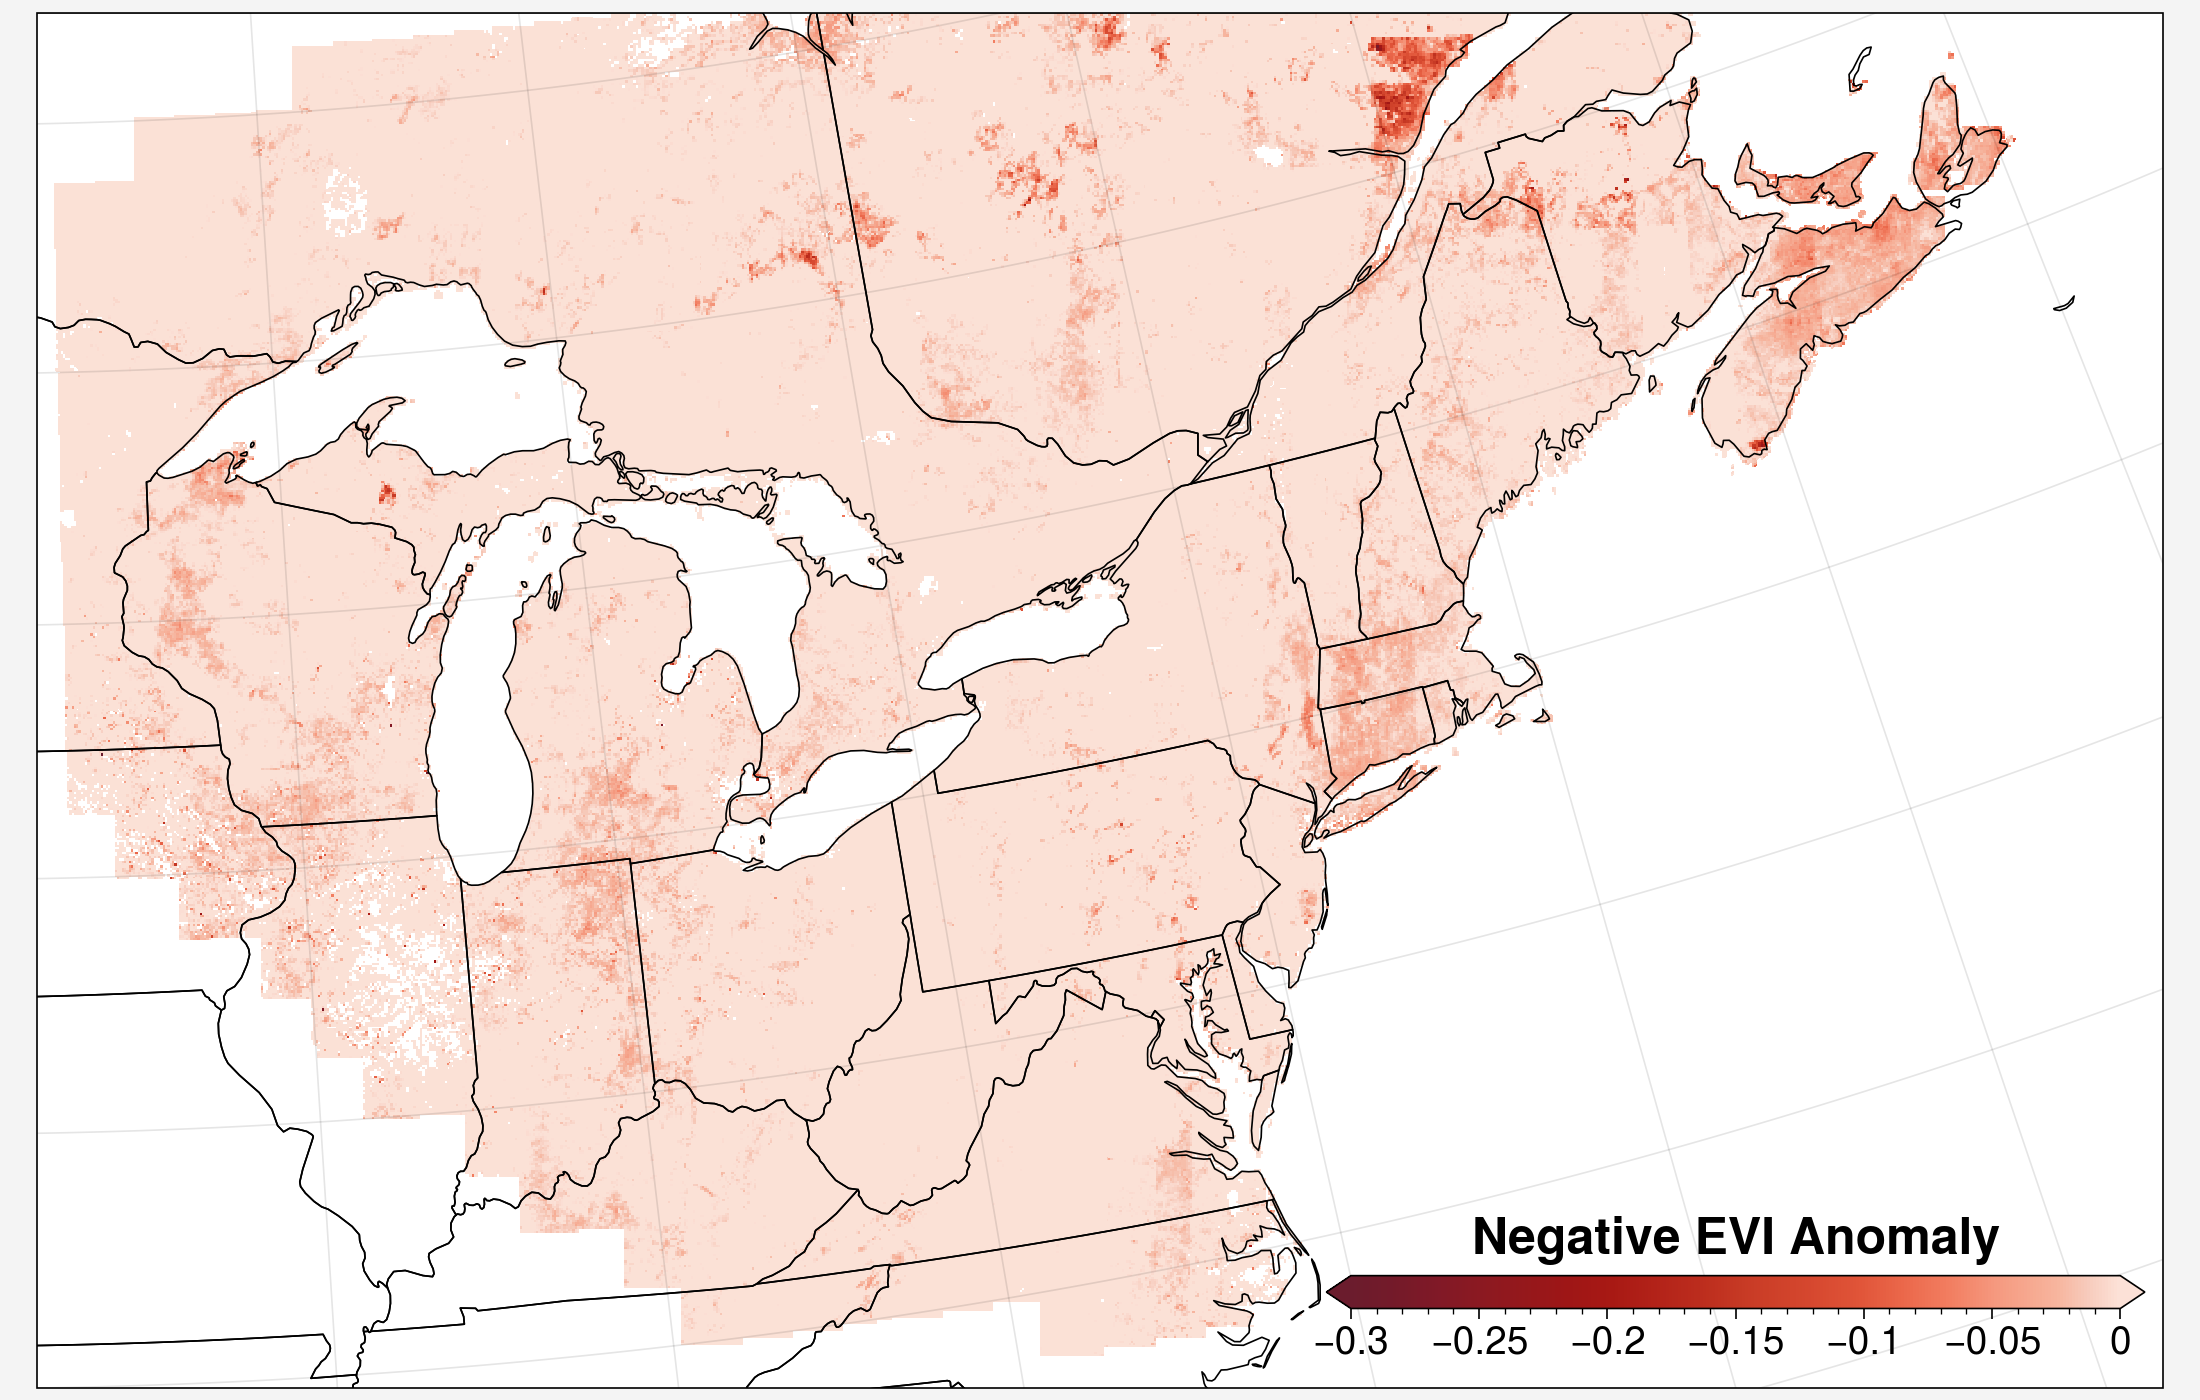

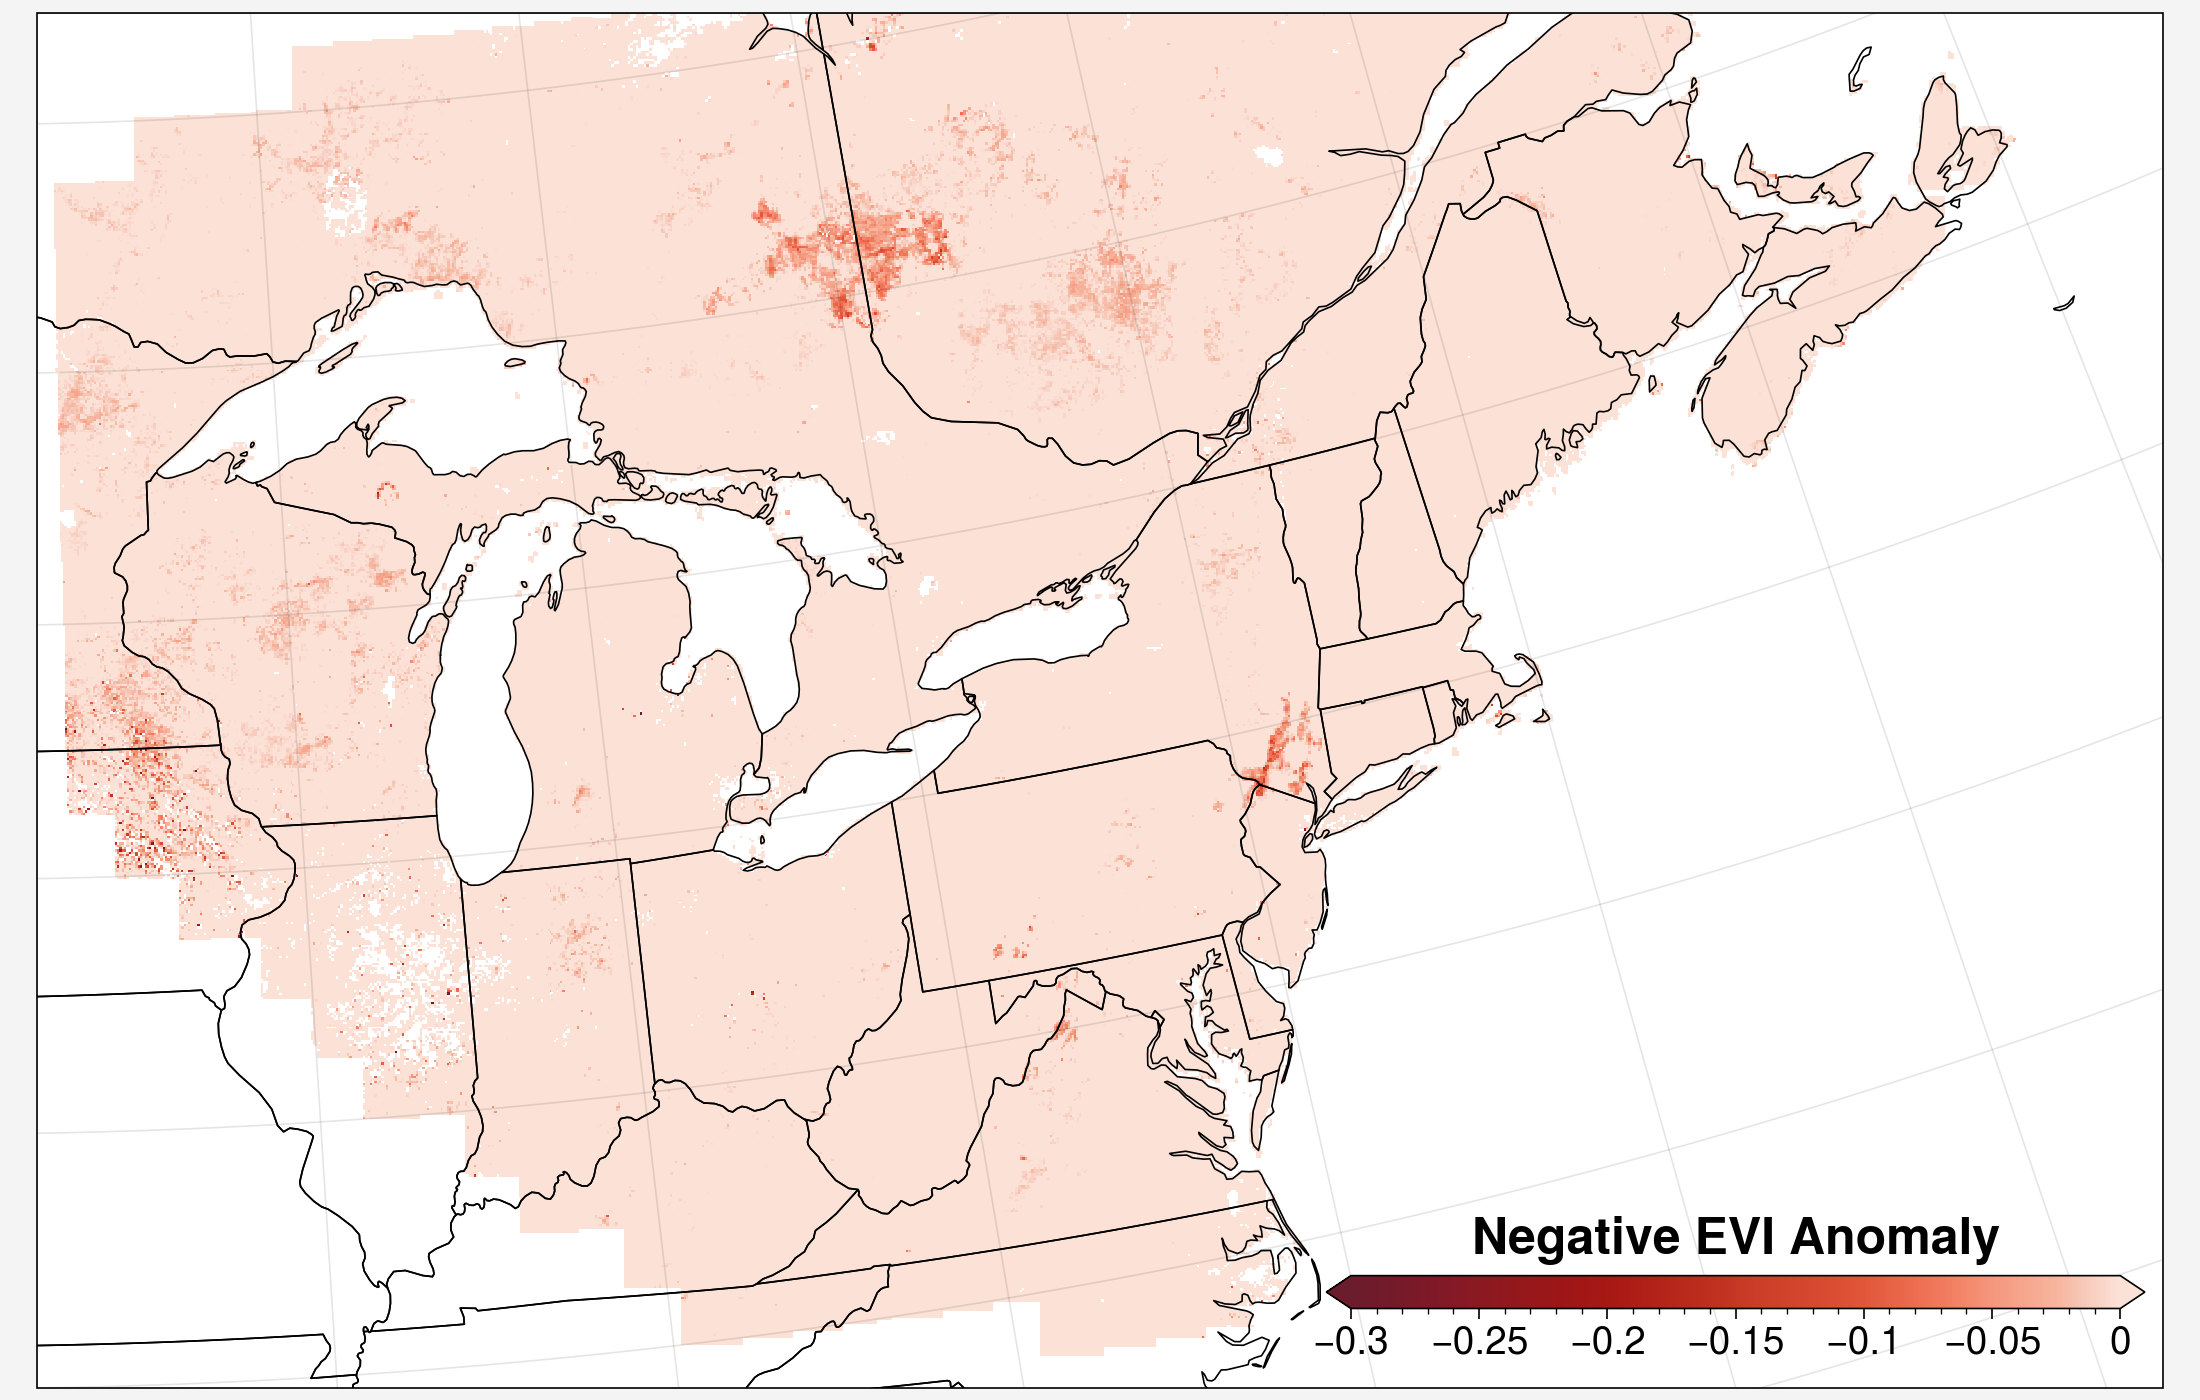

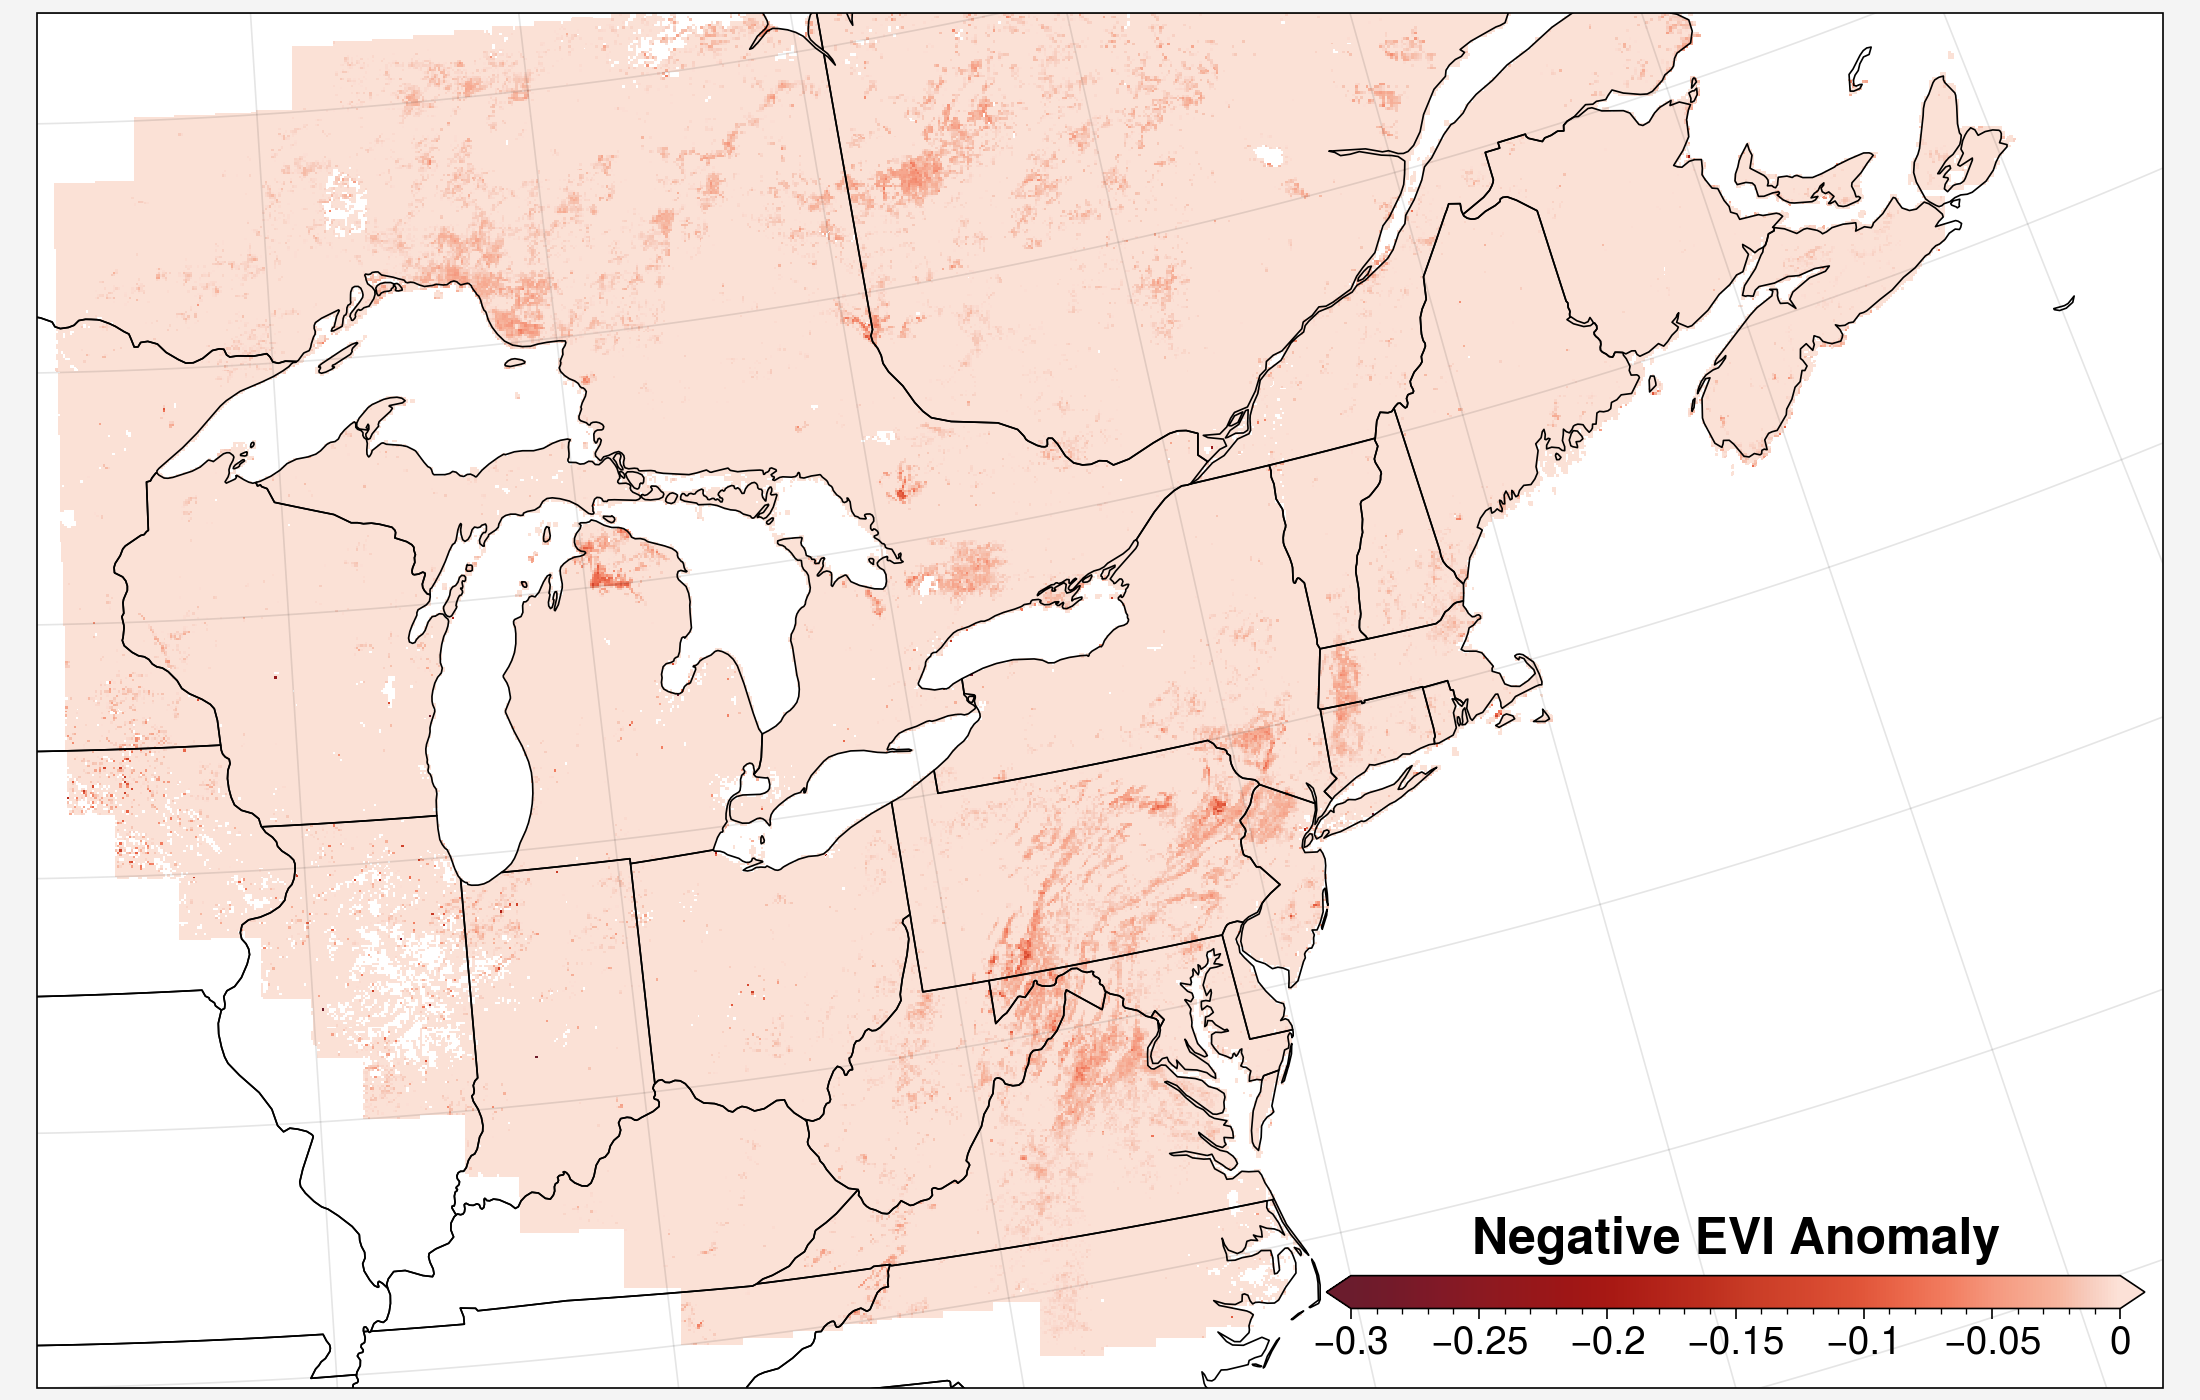

In [3]:
for year in range(2017, 2026):
    dest_crs = ccrs.epsg(5070)
    full_region_bounds = [-94, -58,
                        36, 60]

    fig, ax = uplt.subplots(proj=dest_crs, figsize=(11, 7))

    for i in range(111):
        if (i == 62) or (i == 110):
            continue
        with rio.open(f'../Data/Upscaled/upscaled__{year}_tile_{i}.tif') as src:
            data = src.read()[0, :, :]
            data = data/65_535*2-1
            bounds = src.bounds
        ax.imshow(data, vmin=-0.3, vmax=0, cmap='reds3_r',
                extent=permute_bounds(bounds), 
                origin='upper', transform=dest_crs, zorder=1)
    ax.set_extent(full_region_bounds, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.STATES)
    ax.colorbar('reds3_r', vmin=-0.3, vmax=0, loc='lr', extend='both', 
                frameon=False, length=30, label='Negative EVI Anomaly', 
                labelloc='top', labelsize=18, labelweight='heavy',
                ticklabelsize=14)
    fig.savefig(f'../Figures/upscaled_{year}.png', dpi=300)

In [65]:
np.nanmin(data)

np.float64(-0.057779870443652515)